/Users/amitrana/Documents/work/ai/self-lg/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/amitrana/Documents/work/ai/self-lg/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:27: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


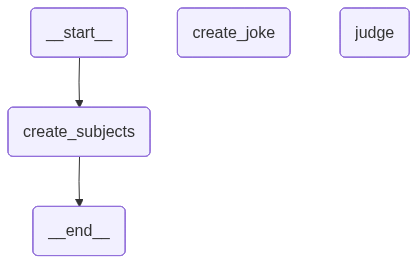

{'best_joke': 'Adopting a dog is choosing a best friend. Adopting a cat is '
              'letting *them* choose you, then wondering if you passed the '
              'interview.',
 'jokes': ["My dog's a Golden Retriever, very proud of his lineage. My cat's a "
           '"Domestic Shorthair," which I think is just fancy for "whatever '
           'showed up and decided it owned the place."',
           "My dog's pet care routine involves daily walks, training, and a "
           "lot of emotional support. My cat's is mostly just making sure the "
           "food bowl isn't *completely* empty and then pretending I don't "
           'exist.',
           'I tried to train my cat. She just stared at me, then yawned, and I '
           "realized *she's* the one who trained *me* to open the tuna can.",
           'My dog eats dirt and seems fine. My cat just sniffed her organic, '
           'grain-free salmon and gave me a look that said, "Is this '
           '*farm-to-bowl*?"',
     

In [1]:
from typing import Annotated, List
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from dotenv import load_dotenv
import operator
from IPython.display import display, Image
from pprint import pprint

load_dotenv()
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


# ----- states -----
class MainState(BaseModel):
    topic: str
    subjects: Annotated[List[str], operator.add] = []
    jokes: Annotated[List[str], operator.add] = []
    best_joke: str = ""


class SubjectsState(BaseModel):
    subjects: List[str]


class JokeState(BaseModel):
    subject: str
    topic: str


# ----- prompts -----
subjects_prompt = PromptTemplate(
    template="You are an AI assistant. Create 4-5 concise subjects for the topic: {topic}. Return as a JSON list (no extra text).",
    input_variables=["topic"],
)
joke_prompt = PromptTemplate(
    template="You are a standup comedian. Provide a short (1-2 line) joke about Topic: {topic} and Subject: {subject}. Return only the joke (no commentary).",
    input_variables=["topic", "subject"],
)
judge_prompt = PromptTemplate(
    template="You are a comedy judge. Pick the single best joke from the list below and return only that joke:\n\n{jokes}",
    input_variables=["jokes"],
)


# ----- nodes -----
def create_subjects(state: MainState):
    structured_llm = llm.with_structured_output(SubjectsState)
    response = structured_llm.invoke(
        [HumanMessage(content=subjects_prompt.format(topic=state.topic))]
    )
    return {"subjects": response.subjects}


def create_joke(state: dict):
    prompt = joke_prompt.format(topic=state["topic"], subject=state["subject"])
    resp = llm.invoke([HumanMessage(content=prompt)])
    return {"jokes": [resp.content.strip()]}


def continue_jokes(state: MainState):
    return [
        Send("create_joke", {"subject": s, "topic": state.topic})
        for s in state.subjects
    ]


def judge(state: MainState):
    prompt = judge_prompt.format(jokes="\n\n".join(state.jokes))
    resp = llm.invoke([HumanMessage(content=prompt)])
    return {"best_joke": resp.content.strip()}


# ----- build graph -----
builder = StateGraph(MainState)
builder.add_node("create_subjects", create_subjects)
builder.add_node("create_joke", create_joke)
builder.add_node("judge", judge)

builder.add_edge(START, "create_subjects")
builder.add_conditional_edges("create_subjects", continue_jokes)
builder.add_edge("create_joke", "judge")
builder.add_edge("judge", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

result = graph.invoke({"topic": "Cats and Dogs"})
pprint(result)